# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証


## データカバレッジ

### 目的

スコアがユニバース（MSCI India IMI）をどの程度カバーしているかを時系列で確認する。カバレッジが低い期間・セグメントがあると、

- 分位分析でスコアの無い銘柄が自動的に除外され、実質的なユニバースが偏る（例: 小型株が抜けて大型株だけの評価になる）
- IC の観測数が減り、統計的な信頼性が落ちる
- 実運用でもスコア欠損銘柄の扱い（中立化・除外）を決める必要がある

ため、後続ステップの解釈に必要な前提として最初に確認する。

### 定義

時点 $t$ のユニバース構成銘柄集合を $U_t$、ユニバースウェイトを $w_{i,t}$、スコアが存在する銘柄集合を $S_t$ とすると

$$
\text{coverage}_t = \frac{|U_t \cap S_t|}{|U_t|}, \qquad
\text{weight coverage}_t = \frac{\sum_{i \in U_t \cap S_t} w_{i,t}}{\sum_{i \in U_t} w_{i,t}}
$$

`univ/` のウェイトは浮動株調整後時価総額に比例するため、weight coverage は「時価総額ベースでどれだけ覆っているか」を表す。
銘柄数ベースと時価総額ベースの差が大きければ、カバレッジがサイズに依存している（通常は大型株ほどカバーされる）ことを意味する。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import pandas as pd

from alphaeval import InputStore, coverage, coverage_summary

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# ---- パラメータ（別のファクターを検証する場合はここを変える）
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
BENCHMARK = "msci_india"
START, END = None, None  # None なら全期間

store = InputStore(INPUT_ROOT)


### 1. データ読み込み

`InputStore` はテンプレート構造（`univ/` `bm/` `alpha/`）を日付 × 銘柄のワイドパネルで返す。
ユニバースは非構成銘柄が NaN、スコアは欠損が NaN。

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
score = store.alpha(SCORE, START, END)

print(f"universe : {univ.shape}  {univ.index.min().date()} 〜 {univ.index.max().date()}")
print(f"benchmark: {bm.shape}  {bm.index.min().date()} 〜 {bm.index.max().date()}")
print(f"score    : {score.shape}  {score.index.min().date()} 〜 {score.index.max().date()}")


universe : (283, 1063)  2003-01-31 〜 2026-07-31
benchmark: (283, 223)  2003-01-31 〜 2026-07-31
score    : (235, 700)  2007-01-31 〜 2026-07-31


スコアの収録期間がユニバースより短い場合、スコア開始前の日付はカバレッジ 0 になる。
以降はスコアが存在する期間に絞って評価する。

In [3]:
score_dates = score.index[score.notna().any(axis=1)]
period = slice(score_dates.min(), score_dates.max())
univ_p, bm_p, score_p = univ.loc[period], bm.loc[period], score.loc[period]
print(f"評価期間: {period.start.date()} 〜 {period.stop.date()}  ({len(univ_p)} か月)")


評価期間: 2007-01-31 〜 2026-07-31  (235 か月)


### 2. カバレッジの時系列

`alphaeval.coverage` は各日付について銘柄数ベース・ウェイトベースのカバレッジと、ユニバース外にスコアが付いている銘柄数を返す。

In [4]:
cov = coverage(score_p, univ_p)
summary = coverage_summary(cov)
display(summary.to_frame("value"))
display(pd.concat([cov.head(3), cov.tail(3)]))


,value
n_dates,235.0
start,2007-01-31 00:00:00
end,2026-07-31 00:00:00
n_universe_mean,363.8
n_covered_mean,255.021277
coverage_mean,0.726561
coverage_min,0.588968
coverage_max,0.984375
weight_coverage_mean,0.923658
n_score_outside_mean,0.0


,n_universe,n_covered,coverage,weight_coverage,n_score_total,n_score_outside
2007-01-31,52.0,51.0,0.980769,0.606135,51.0,0.0
2007-02-28,52.0,51.0,0.980769,0.577513,51.0,0.0
2007-03-31,53.0,52.0,0.981132,0.568032,52.0,0.0
2026-05-31,620.0,444.0,0.716129,0.924845,444.0,0.0
2026-06-30,624.0,446.0,0.714744,0.919489,446.0,0.0
2026-07-31,622.0,444.0,0.713826,0.921714,444.0,0.0


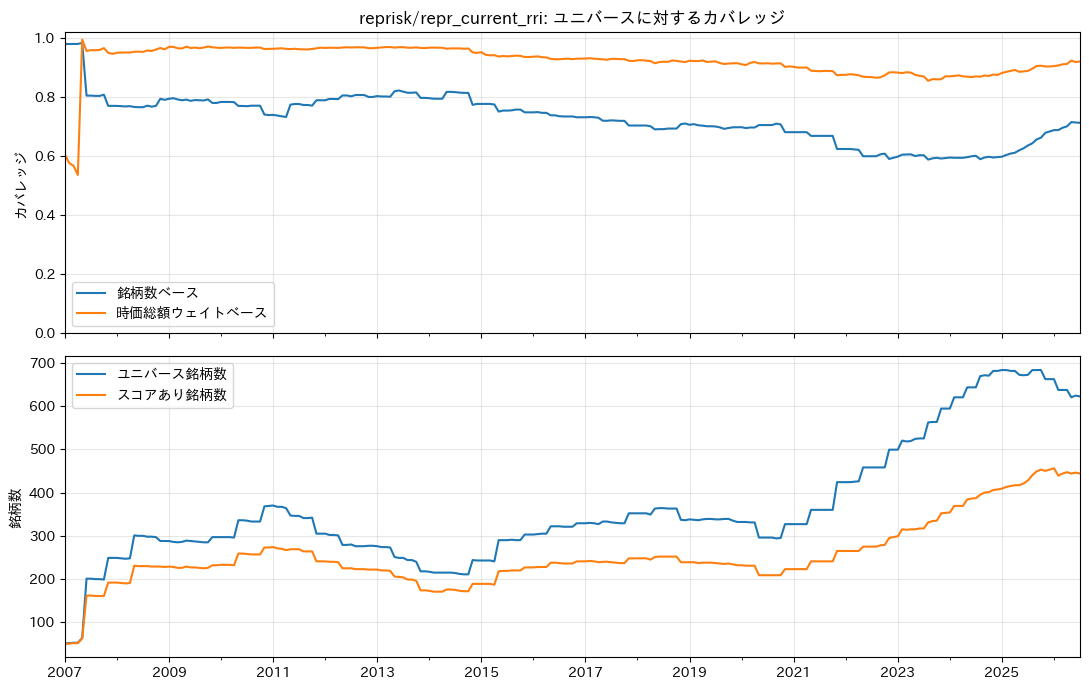

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
cov[["coverage", "weight_coverage"]].plot(ax=axes[0])
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel("カバレッジ")
axes[0].set_title(f"{SCORE}: ユニバースに対するカバレッジ")
axes[0].legend(["銘柄数ベース", "時価総額ウェイトベース"])
axes[0].grid(alpha=0.3)
cov[["n_universe", "n_covered"]].plot(ax=axes[1])
axes[1].set_ylabel("銘柄数")
axes[1].legend(["ユニバース銘柄数", "スコアあり銘柄数"])
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3. ベンチマーク内外（大型・中型 vs 小型）のカバレッジ

MSCI India（ベンチマーク）の構成銘柄は大型・中型、それ以外の IMI 銘柄は小型に相当する。
ユニバースをベンチマーク構成銘柄とそれ以外に分けて、それぞれのカバレッジを見る。
小型側のカバレッジが低いと、分位分析の Q1 / Q5 がサイズバイアスを持ちやすい。

,平均カバレッジ,最小,平均銘柄数,平均スコアあり銘柄数
ベンチマーク内（大型・中型）,0.952,0.877,87.689,82.643
ベンチマーク外（小型）,0.648,0.497,276.111,172.379
全体,0.727,0.589,363.800,255.021


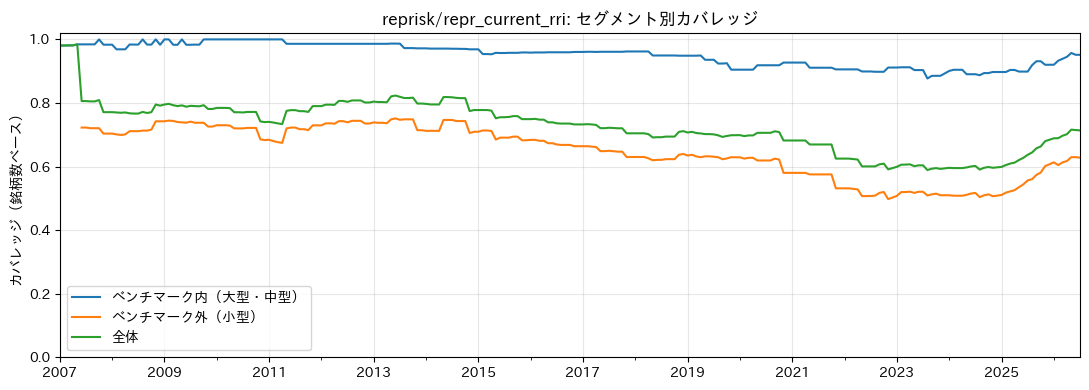

In [6]:
in_bm = univ_p.where(bm_p.reindex(index=univ_p.index, columns=univ_p.columns).notna())
out_bm = univ_p.where(bm_p.reindex(index=univ_p.index, columns=univ_p.columns).isna())
cov_in = coverage(score_p, in_bm)
cov_out = coverage(score_p, out_bm)

seg = pd.DataFrame(
    {
        "ベンチマーク内（大型・中型）": cov_in["coverage"],
        "ベンチマーク外（小型）": cov_out["coverage"],
        "全体": cov["coverage"],
    }
)
display(
    pd.DataFrame(
        {
            "平均カバレッジ": seg.mean(),
            "最小": seg.min(),
            "平均銘柄数": [cov_in["n_universe"].mean(), cov_out["n_universe"].mean(), cov["n_universe"].mean()],
            "平均スコアあり銘柄数": [cov_in["n_covered"].mean(), cov_out["n_covered"].mean(), cov["n_covered"].mean()],
        }
    ).round(3)
)

ax = seg.plot(figsize=(11, 4))
ax.set_ylim(0, 1.02)
ax.set_ylabel("カバレッジ（銘柄数ベース）")
ax.set_title(f"{SCORE}: セグメント別カバレッジ")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4. 年別サマリー

期間ごとの傾向を数表で確認する（年ごとの平均）。

In [7]:
yearly = pd.DataFrame(
    {
        "n_universe": cov["n_universe"],
        "n_covered": cov["n_covered"],
        "coverage": cov["coverage"],
        "weight_coverage": cov["weight_coverage"],
        "coverage_in_bm": cov_in["coverage"],
        "coverage_out_bm": cov_out["coverage"],
    }
).groupby(cov.index.year).mean().round(3)
display(yearly)


,n_universe,n_covered,coverage,weight_coverage,coverage_in_bm,coverage_out_bm
2007,147.750,121.667,0.873,0.832,0.984,0.716
2008,280.167,216.667,0.773,0.957,0.983,0.714
2009,288.250,227.750,0.790,0.969,0.992,0.738
2010,327.500,252.000,0.771,0.968,1.000,0.718
2011,345.083,263.583,0.765,0.965,0.991,0.707
2012,285.833,229.000,0.801,0.968,0.986,0.739
2013,250.833,203.167,0.810,0.969,0.981,0.739
2014,218.917,175.667,0.803,0.964,0.970,0.728
2015,276.417,210.333,0.762,0.941,0.958,0.697
2016,317.000,234.500,0.740,0.933,0.959,0.673


### 5. 所見

- スコアの収録期間は 2007-01〜2026-07（235 か月）。ユニバース全期間（2003-01〜）より 4 年短い。
- 銘柄数ベースの平均カバレッジは 73%（最小 59%、最大 98%）、時価総額ウェイトベースでは 92%。
  両者の差が大きく、**カバレッジはサイズに強く依存する**（大型株ほど RRI が付いている）。
- ベンチマーク内（大型・中型）は平均 95%、最小 88%。ベンチマーク外（小型）は平均 65%、最小 50%。
  小型株の 3 分の 1 以上にスコアが無い。
- 2021〜2024 年に IMI の銘柄数が約 360 → 680 へ急増した局面で全体カバレッジが 60% 前後まで低下（小型側は 51%）。
  新規組入の小型株に RRI が付くまでラグがあるとみられ、2025 年以降は回復傾向（2026 年 70%）。
- 2007 年は銘柄数ベースは 98% だが時価総額ベースが 60% 前後と低い。ユニバースが 50 銘柄程度しかない初期で、
  時価総額の大きい少数銘柄が未カバーだったため。この期間は検証に使わない方がよい。

**後続ステップへの含意**

- 分位分析は「スコアのある銘柄」だけで分位を切るため、実質ユニバースは大型寄りになる。
  RRI 単独の Q1 / Q5 のリターン差にはサイズ効果が混入しうるので、ベンチマーク内に絞った分位分析や
  サイズ中立化したスコアを並走させて確認する。
- IC の観測数は月あたり 250 銘柄前後で十分。ただし 2007〜2008 年は 120〜200 銘柄でやや不安定。
- 次は `02_distribution.ipynb` でスコアの分布と同順位、スコア帯のサイズを確認する。